In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# Load one image and one label
img = nib.load(r'D:\dental-segmentation\data\raw\CBCT_upload\images\a1000.nii')
lbl = nib.load(r'D:\dental-segmentation\data\raw\CBCT_upload\labels\a1000.nii')

img_data = img.get_fdata()
lbl_data = lbl.get_fdata()

print("Image shape:", img_data.shape)
print("Image min/max:", img_data.min(), img_data.max())
print("Label shape:", lbl_data.shape)
print("Unique label values:", np.unique(lbl_data))


Image shape: (400, 400, 435)
Image min/max: 0.0 1.0
Label shape: (400, 400, 435)
Unique label values: [ 0.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 18. 19.
 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30.]


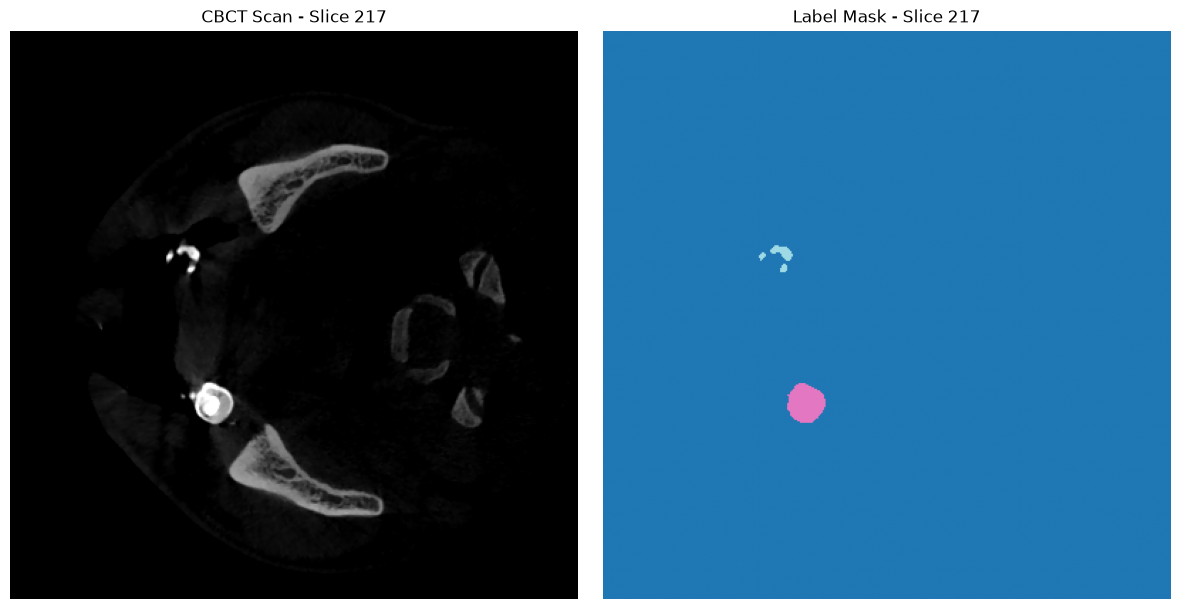

In [2]:
# Pick the middle slice
mid = img_data.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_data[:, :, mid], cmap='gray')
axes[0].set_title(f'CBCT Scan - Slice {mid}')
axes[0].axis('off')

axes[1].imshow(lbl_data[:, :, mid], cmap='tab20')
axes[1].set_title(f'Label Mask - Slice {mid}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Best slice index: 178


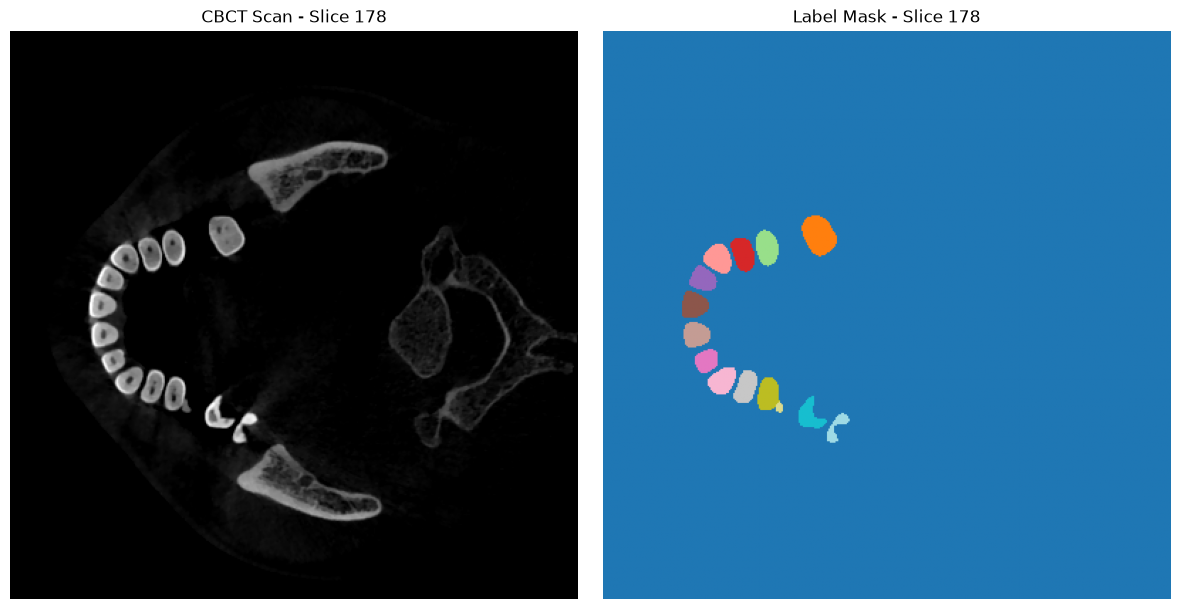

In [3]:
# Find slice with most label content
tooth_counts = [(i, np.sum(lbl_data[:, :, i] > 0)) for i in range(lbl_data.shape[2])]
best_slice = max(tooth_counts, key=lambda x: x[1])[0]
print("Best slice index:", best_slice)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_data[:, :, best_slice], cmap='gray')
axes[0].set_title(f'CBCT Scan - Slice {best_slice}')
axes[0].axis('off')

axes[1].imshow(lbl_data[:, :, best_slice], cmap='tab20')
axes[1].set_title(f'Label Mask - Slice {best_slice}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import sys
sys.path.insert(0, 'D:\\dental-segmentation\\src')

import torch
from model import UNet

model = UNet()
x = torch.randn(1, 1, 400, 400)
out = model(x)
print("Input shape:", x.shape)
print("Output shape:", out.shape)
print("Model parameters:", sum(p.numel() for p in model.parameters()))

Input shape: torch.Size([1, 1, 400, 400])
Output shape: torch.Size([1, 1, 400, 400])
Model parameters: 7762465


In [5]:
import sys
sys.path.insert(0, 'D:\\dental-segmentation\\src')

from dataset import DentalDataset, get_file_splits

IMAGE_DIR = r"D:\dental-segmentation\data\raw\CBCT_upload\images"
LABEL_DIR = r"D:\dental-segmentation\data\raw\CBCT_upload\labels"

# Test splits
(train_imgs, train_lbls), (val_imgs, val_lbls), (test_imgs, test_lbls) = \
    get_file_splits(IMAGE_DIR, LABEL_DIR)

print(f"Train files: {len(train_imgs)}")
print(f"Val files: {len(val_imgs)}")
print(f"Test files: {len(test_lbls)}")

# Test dataset loading
dataset = DentalDataset(IMAGE_DIR, LABEL_DIR)
img, lbl = dataset[0]
print(f"\nSample image shape: {img.shape}")
print(f"Sample label shape: {lbl.shape}")
print(f"Image range: {img.min():.2f} - {img.max():.2f}")
print(f"Label unique values: {lbl.unique()}")

Train files: 35
Val files: 7
Test files: 8
Indexing dataset...
Total slices: 21750

Sample image shape: torch.Size([1, 400, 400])
Sample label shape: torch.Size([1, 400, 400])
Image range: 0.00 - 1.00
Label unique values: tensor([0.])


In [5]:
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm
import gc

IMAGE_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\images")
LABEL_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\labels")
OUT_DIR_D = Path(r"D:\dental-segmentation\data\processed")
OUT_DIR_C = Path(r"C:\dental-processed")

OUT_DIR_C.mkdir(exist_ok=True)

image_files = sorted(IMAGE_DIR.glob("*.nii"))
label_files = sorted(LABEL_DIR.glob("*.nii"))

for img_path, lbl_path in tqdm(zip(image_files, label_files), total=len(image_files)):
    name = img_path.stem
    
    # Skip if already processed on D
    if (OUT_DIR_D / f"{name}_img.npy").exists():
        continue
    
    img_data = np.ascontiguousarray(
        nib.load(str(img_path)).get_fdata(dtype=np.float32)
    )
    if img_data.max() > 0:
        img_data = img_data / img_data.max()
    np.save(OUT_DIR_C / f"{name}_img.npy", img_data)
    del img_data
    gc.collect()
    
    lbl_data = np.ascontiguousarray(
        nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    )
    lbl_data = (lbl_data > 0).astype(np.float32)
    np.save(OUT_DIR_C / f"{name}_lbl.npy", lbl_data)
    del lbl_data
    gc.collect()

print("Done!")

100%|██████████| 50/50 [02:12<00:00,  2.66s/it]

Done!


In [6]:
from pathlib import Path

processed = Path(r"D:\dental-segmentation\data\processed")
image_dir = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\images")

image_files = sorted(image_dir.glob("*.nii"))
for f in image_files:
    img_npy = processed / f"{f.stem}_img.npy"
    lbl_npy = processed / f"{f.stem}_lbl.npy"
    if not img_npy.exists() or not lbl_npy.exists():
        print(f"Missing: {f.stem}")

Missing: a1050
Missing: a1052
Missing: a1060
Missing: a1061


In [7]:
import nibabel as nib
import numpy as np
from pathlib import Path
import gc

IMAGE_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\images")
LABEL_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\labels")
OUT_DIR = Path(r"D:\dental-segmentation\data\processed")

missing = ["a1050", "a1052", "a1060", "a1061"]

for name in missing:
    print(f"Processing {name}...")
    
    img_data = np.ascontiguousarray(
        nib.load(str(IMAGE_DIR / f"{name}.nii")).get_fdata(dtype=np.float32)
    )
    if img_data.max() > 0:
        img_data = img_data / img_data.max()
    np.save(OUT_DIR / f"{name}_img.npy", img_data)
    del img_data
    gc.collect()
    
    lbl_data = np.ascontiguousarray(
        nib.load(str(LABEL_DIR / f"{name}.nii")).get_fdata(dtype=np.float32)
    )
    lbl_data = (lbl_data > 0).astype(np.float32)
    np.save(OUT_DIR / f"{name}_lbl.npy", lbl_data)
    del lbl_data
    gc.collect()
    
    print(f"{name} done!")

print("All missing files processed!")

Processing a1050...
a1050 done!
Processing a1052...
a1052 done!
Processing a1060...


OSError: 69600000 requested and 0 written

In [8]:
from pathlib import Path
import numpy as np

processed = Path(r"D:\dental-segmentation\data\processed")
broken = []

for f in sorted(processed.glob("*_lbl.npy")):
    size = f.stat().st_size
    if size < 1000:
        broken.append(f.name)
        print(f"Broken: {f.name} ({size} bytes)")

print(f"\nTotal broken: {len(broken)}")


Broken: a1060_lbl.npy (128 bytes)

Total broken: 1


In [9]:
import os
os.remove(r"D:\dental-segmentation\data\processed\a1060_lbl.npy")
os.remove(r"D:\dental-segmentation\data\processed\a1060_img.npy")
print("Deleted")

Deleted


In [10]:
import nibabel as nib
import numpy as np
from pathlib import Path
import gc

name = "a1060"
IMAGE_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\images")
LABEL_DIR = Path(r"D:\dental-segmentation\data\raw\CBCT_upload\labels")
OUT_DIR = Path(r"C:\dental-processed2")
OUT_DIR.mkdir(exist_ok=True)

img_data = np.ascontiguousarray(
    nib.load(str(IMAGE_DIR / f"{name}.nii")).get_fdata(dtype=np.float32)
)
if img_data.max() > 0:
    img_data = img_data / img_data.max()
np.save(OUT_DIR / f"{name}_img.npy", img_data)
del img_data
gc.collect()

lbl_data = np.ascontiguousarray(
    nib.load(str(LABEL_DIR / f"{name}.nii")).get_fdata(dtype=np.float32)
)
lbl_data = (lbl_data > 0).astype(np.float32)
np.save(OUT_DIR / f"{name}_lbl.npy", lbl_data)
del lbl_data
gc.collect()

print("Done!")

Done!
